### From the sunpy example 
https://docs.sunpy.org/en/stable/generated/gallery/plotting/solar_cycle_example.html

In [83]:
#Imports
import matplotlib.pyplot as plt

import astropy.units as u
from astropy.time import Time, TimeDelta
from astropy.visualization import time_support

import sunpy.timeseries as ts
from sunpy.net import Fido
from sunpy.net import attrs as a
from sunpy.time import TimeRange

import numpy as np

In [84]:
# get data
time_range = TimeRange("1994-01-01 00:00", Time.now()) # I've used the start of the year before the C23 minimum that Tindale and Chapman (2017) use
result = Fido.search(a.Time(time_range), a.Instrument('noaa-indices')) # fido search for the noaa indices in the time range
f_noaa_indices = Fido.fetch(result)
result = Fido.search(a.Time(time_range.end, time_range.end + TimeDelta(4 * u.year)),
                     a.Instrument('noaa-predict')) # get the predicted sunspot numbers from NOAA (4 years in future)
f_noaa_predict = Fido.fetch(result)

Files Downloaded: 100%|██████████| 1/1 [00:00<00:00,  9.68file/s]
/Users/ruthhyndman_1/miniforge3/envs/sunpyVenv/lib/python3.14/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "taiutc" yielded 1 of "dubious year (Note 4)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/Users/ruthhyndman_1/miniforge3/envs/sunpyVenv/lib/python3.14/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "d2dtf" yielded 1 of "dubious year (Note 5)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
Files Downloaded: 100%|██████████| 1/1 [00:00<00:00,  2.41file/s]


In [96]:
#loading data into TimeSeries objects
noaa = ts.TimeSeries(f_noaa_indices, source='noaaindices').truncate(time_range) 
noaa_predict = ts.TimeSeries(f_noaa_predict, source='noaapredictindices')

/Users/ruthhyndman_1/miniforge3/envs/sunpyVenv/lib/python3.14/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "dtf2d" yielded 1 of "dubious year (Note 6)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/Users/ruthhyndman_1/miniforge3/envs/sunpyVenv/lib/python3.14/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "dtf2d" yielded 1 of "dubious year (Note 6)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
2026-08-05 17:05:34 - sunpy - WARNING: SunpyUserWarning: Unknown units for high25_ssn
2026-08-05 17:05:34 - sunpy - WARNING: SunpyUserWarning: Unknown units for high75_ssn
2026-08-05 17:05:34 - sunpy - WARNING: SunpyUserWarning: Unknown units for low25_ssn
2026-08-05 17:05:34 - sunpy - WARNING: SunpyUserWarning: Unknown units for low75_ssn
2026-08-05 17:05:34 - sunpy - WARNING: SunpyUserWarning: Unknown units for high25_f10.7
2026-08-05 17:05:34 - sunpy - WARNING: SunpyUserWarning: Unknown units for high75_f10.7
2026-08-05 17:05

In [120]:
TitleSize = 25
AxisSize = 20
TickSize = 15

<bound method GenericTimeSeries.quantity of <sunpy.timeseries.sources.noaa.NOAAIndicesTimeSeries object at 0x3475c8af0>
SunPy TimeSeries
----------------
Observatory:			Unknown
Instrument:			<a href=https://www.swpc.noaa.gov/products/solar-cycle-progression target="_blank">Unknown</a>
Channel(s):			sunspot RI<br>sunspot RI smooth<br>sunspot SWO<br>sunspot SWO smooth<br>radio flux<br>radio flux smooth
Start Date:			1996-05-01 00:00:00
End Date:			1996-05-01 00:00:00
Center Date:			1996-05-01 00:00:00
Resolution:			0.0 s
Samples per Channel:		1
Data Range(s):		sunspot RI           0.00E+00<br>sunspot RI smooth    0.00E+00<br>sunspot SWO               NaN<br>sunspot SWO smooth        NaN<br>radio flux                NaN<br>radio flux smooth         NaN
Units:			dimensionless<br>W / (Hz m2)
            sunspot RI  sunspot RI smooth  sunspot SWO  sunspot SWO smooth  \
1996-05-01         7.6               11.2          NaN                 NaN   

            radio flux  radio flux smooth  
1

/Users/ruthhyndman_1/miniforge3/envs/sunpyVenv/lib/python3.14/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "dtf2d" yielded 1 of "dubious year (Note 6)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


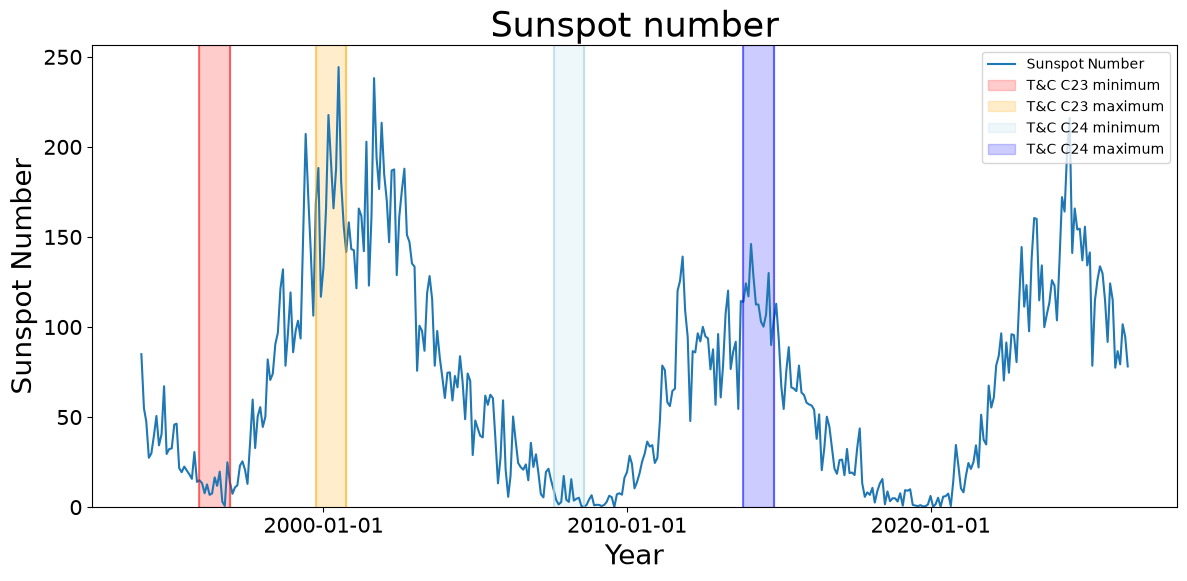

In [139]:
time_support()
fig, ax = plt.subplots(figsize=(14,6))
ax.plot(noaa.time, noaa.quantity('sunspot RI'), label='Sunspot Number')
# ax.plot(
#     noaa_predict.time, noaa_predict.quantity('sunspot'),
#     color='grey', label='Near-term Prediction'
# )
# ax.fill_between(
#     noaa_predict.time, noaa_predict.quantity('sunspot low'),
#     noaa_predict.quantity('sunspot high'), alpha=0.3, color='grey'
# )
ax.set_ylim(bottom=0)
ax.set_ylabel('Sunspot Number', fontsize=AxisSize)
ax.set_xlabel('Year', fontsize=AxisSize)

# times = []
# for t in range(10):
#     times.append(Time('1994-01-01').jd1-2400000 + 4*t*( (Time('1996-01-01').jd1-2400000) - (Time('1995-01-01').jd1-2400000) ) )
# plt.xticks(times, fontsize=TickSize)

plt.xticks(fontsize=TickSize)
plt.yticks(fontsize=TickSize)
plt.title("Sunspot number", fontsize=TitleSize)

# print(noaa.time[0])

#Tindale and Chapman - "These dates were chosen based on the sunspot number, as in Hush et al. (2015)."

#C23 - Min
ax.axvline(Time('1995-12-01').jd1-2400000, color='red', alpha = 0.5)
ax.axvline(Time('1996-11-30').jd1-2400000, color='red', alpha = 0.5)
ax.axvspan(Time('1995-12-01').jd1-2400000, Time('1996-11-30').jd1-2400000, color='red', alpha=0.2, label = "T&C C23 minimum")
C23MinMidtimerange = TimeRange("1996-05-01", "1996-05-31") # I've used the start of the year before the C23 minimum that Tindale and Chapman (2017) use
C23MinMid = ts.TimeSeries(f_noaa_indices, source='noaaindices').truncate(C23MinMidtimerange)
# C23Mintime_range = TimeRange("1995-12-01", "1996-11-30") # I've used the start of the year before the C23 minimum that Tindale and Chapman (2017) use
# C23Minimum = ts.TimeSeries(f_noaa_indices, source='noaaindices').truncate(C23Mintime_range)
print(C23MinMid.quantity) 
# ax.axvline(Time('1996-05-01').jd1-2400000, color='red')

#C23 - Max
ax.axvline(Time('1999-10-01').jd1-2400000, color='orange', alpha = 0.5)
ax.axvline(Time('2000-09-30').jd1-2400000, color='orange', alpha = 0.5)
ax.axvspan(Time('1999-10-01').jd1-2400000, Time('2000-09-30').jd1-2400000, color='orange', alpha=0.2, label = "T&C C23 maximum")

# C24 - Min
ax.axvline(Time('2007-08-01').jd1-2400000, color='lightblue', alpha = 0.7)
ax.axvline(Time('2008-07-31').jd1-2400000, color='lightblue', alpha = 0.7)
ax.axvspan(Time('2007-08-01').jd1-2400000, Time('2008-07-31').jd1-2400000, color='lightblue', alpha=0.2, label = "T&C C24 minimum")

#C24 - Max
ax.axvline(Time('2013-11-01').jd1-2400000, color='blue', alpha = 0.5)
ax.axvline(Time('2014-10-31').jd1-2400000, color='blue', alpha = 0.5)
ax.axvspan(Time('2013-11-01').jd1-2400000, Time('2014-10-31').jd1-2400000, color='blue', alpha=0.2, label = "T&C C24 maximum")

ax.legend()
plt.show()